In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl

In [4]:
mpl.rcParams['figure.figsize'] = [16.0, 8.0]

In [5]:
df = pd.read_csv("assets/wipeout.csv")

df.head()

,timestamp,cadence,distance,enhanced_altitude,enhanced_speed,fractional_cadence,heart_rate,position_lat,position_long,speed,timestamp.1,position_lat_degrees,position_long_degrees
0,2019-11-01 20:12:03,NaN,0.00,281.6,0.000,NaN,84.0,504424439.0,-999065791.0,NaN,2019-11-01 20:12:03,42.280368,-83.740727
1,2019-11-01 20:12:04,NaN,0.00,281.6,0.000,NaN,84.0,504424439.0,-999065791.0,NaN,2019-11-01 20:12:04,42.280368,-83.740727
2,2019-11-01 20:12:07,NaN,0.00,281.6,0.000,NaN,87.0,504424439.0,-999065791.0,NaN,2019-11-01 20:12:07,42.280368,-83.740727
3,2019-11-01 20:12:08,NaN,0.32,281.6,1.036,NaN,88.0,504424447.0,-999065835.0,NaN,2019-11-01 20:12:08,42.280369,-83.740731
4,2019-11-01 20:12:10,NaN,3.30,281.8,2.976,NaN,89.0,504424476.0,-999066382.0,NaN,2019-11-01 20:12:10,42.280371,-83.740777


In [6]:
import math
df["position_lat_degrees"] = df["position_lat"] * ( 180 / 2**31 )
df["position_long_degrees"] = df["position_long"] * ( 180 / 2**31 )

def lat2y(a):
  return 180.0/math.pi*math.log(math.tan(math.pi/4.0+a*(math.pi/180.0)/2.0))
df["position_lat_degrees_mercantor"]=df["position_lat_degrees"].apply(lat2y)

df=df[['timestamp','enhanced_altitude','enhanced_speed','heart_rate','position_lat_degrees_mercantor',
       'position_long_degrees','position_lat_degrees']].dropna()
df.head()

,timestamp,enhanced_altitude,enhanced_speed,heart_rate,position_lat_degrees_mercantor,position_long_degrees,position_lat_degrees
0,2019-11-01 20:12:03,281.6,0.000,84.0,46.739975,-83.740727,42.280368
1,2019-11-01 20:12:04,281.6,0.000,84.0,46.739975,-83.740727,42.280368
2,2019-11-01 20:12:07,281.6,0.000,87.0,46.739975,-83.740727,42.280368
3,2019-11-01 20:12:08,281.6,1.036,88.0,46.739976,-83.740731,42.280369
4,2019-11-01 20:12:10,281.8,2.976,89.0,46.739979,-83.740777,42.280371


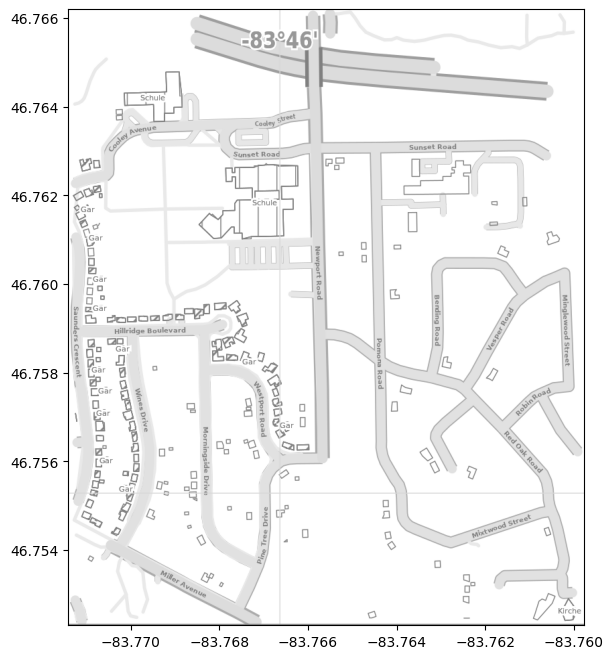

In [7]:
image=plt.imread("assets/map.png")
plt.imshow(image, alpha=0.5, extent=[-83.77141,-83.75977,46.75230,46.76620])

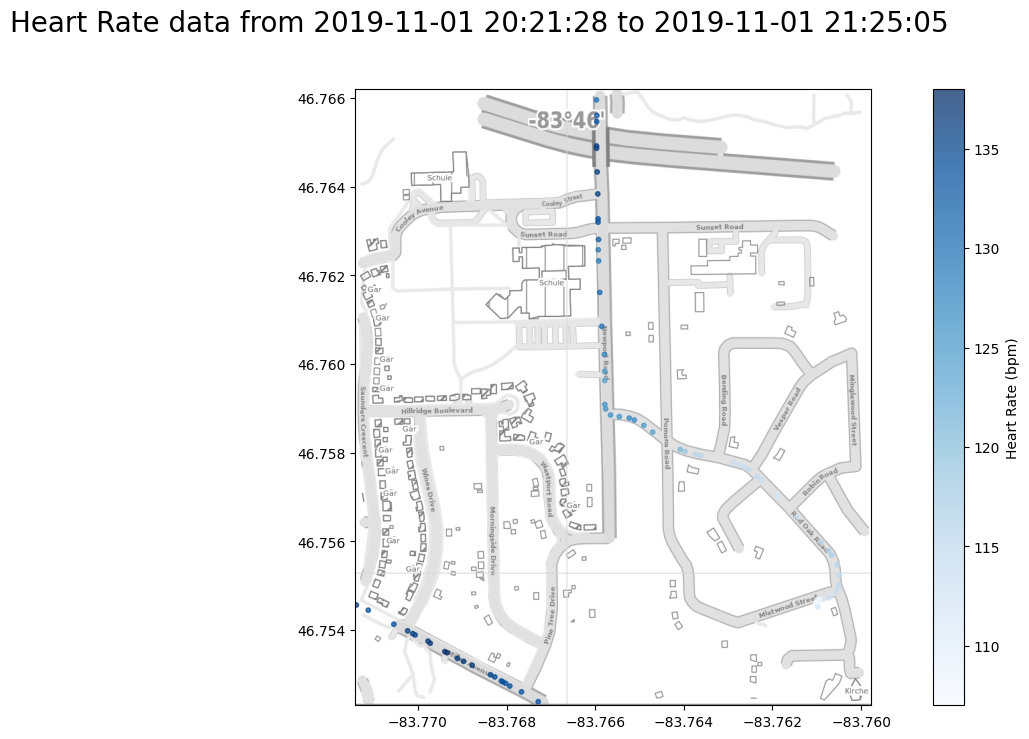

In [8]:
plt.imshow(image, alpha=0.5, extent=[-83.77141,-83.75977,46.75230,46.76620])

small_df = df[(df["position_long_degrees"] > -83.77141) &
              (df["position_long_degrees"] < -83.75977) &
              (df["position_lat_degrees_mercantor"] > 46.75230) &
              (df["position_lat_degrees_mercantor"] < 46.76620)]
   
plt.scatter(small_df["position_long_degrees"],small_df["position_lat_degrees_mercantor"],
            s=10, c=small_df["heart_rate"], cmap='Blues', alpha=0.75)

plt.colorbar().set_label("Heart Rate (bpm)")

plt.suptitle("Heart Rate data from {} to {}".format(np.min(small_df["timestamp"]),np.max(small_df["timestamp"])),size='20');

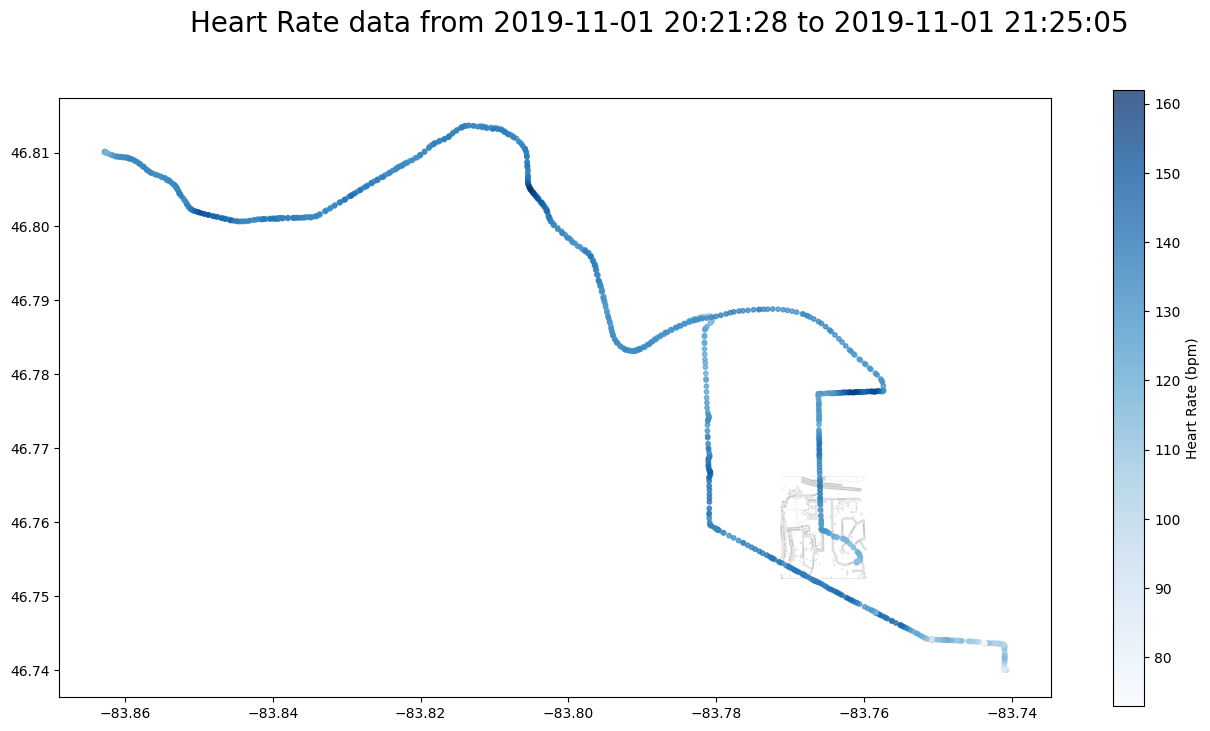

In [9]:
plt.imshow(image, alpha=0.5, extent=[-83.77141,-83.75977,46.75230,46.76620])
plt.scatter(df["position_long_degrees"],df["position_lat_degrees_mercantor"],
            s=10, c=df["heart_rate"], cmap='Blues', alpha=0.75)
plt.colorbar().set_label("Heart Rate (bpm)")
plt.suptitle("Heart Rate data from {} to {}".format(np.min(small_df["timestamp"]),np.max(small_df["timestamp"])),size='20');

In [12]:
import folium

m = folium.Map(location=[42.24, -83.764], zoom_start=12)

m.save("map.html")

In [13]:
m=folium.Map(location=[42.296,-83.768], zoom_start=15)
folium.Marker([df["position_lat_degrees"].iloc[0],df["position_long_degrees"].iloc[0]], 
              popup="Start").add_to(m)
folium.Marker([df["position_lat_degrees"].iloc[-1],df["position_long_degrees"].iloc[-1]], 
              popup="Stop").add_to(m)


route=folium.PolyLine(locations=zip(df["position_lat_degrees"],df["position_long_degrees"]),
                    weight=5,color='blue').add_to(m)


m.save("map2.html")